# Improving earthquake metadata for GNSS time series analysis using Okada-based co-seismic deformation modelling
# ***Finite Source Coseismic Slip Plots***
*** 
***

## **0. Finite Source Formulae** ##

In [1]:
def coords (stalon, stalat, evlon, evlat, evdep, strike, dip, rake, mu, lam, U, W):
    distance_m, azimuth, baz = gps2dist_azimuth(evlat, evlon, stalat, stalon)
    dEast = distance_m*np.sin(azimuth*np.pi/180.0) #m
    dNorth = distance_m*np.cos(azimuth*np.pi/180.0) #m

    x = dEast * np.sin(strike*np.pi/180.0) + dNorth * np.cos(strike*np.pi/180.0) #m
    y = -dEast * np.cos(strike*np.pi/180.0) + dNorth * np.sin(strike*np.pi/180.0) #m

    d = abs(evdep) #m
    delta = dip*np.pi/180.0 #radians
    
    p = y*np.cos(delta)+d*np.sin(delta) #m
    q = y*np.sin(delta)-d*np.cos(delta) #m

    mu = 10**9*mu #convert GPa to N/m^2
    lam = 10**9*lam #convert GPa to N/m^2
    return(
        U*np.cos(rake*np.pi/180.0), #m #U1
        U*np.sin(rake*np.pi/180.0), #m #U2
        x, #m #x
        y, #m #y
        d, #m #d
        mu, #GPa->N/m^2 #mu
        lam, #GPa->N/m^2 #lam
        delta, #rad #delta
        p, #m #p
        q #m #q
    )

In [2]:
def chinnery (x, p, q, L, W, delta):
        xi = [x+L/2,x-L/2] #m #xi
        eta = [p+W/2,p-W/2] #m #eta

        ytil = [0,0]
        dtil = [0,0]
        R = [[0,0],[0,0]]
        X = [0,0]

        for i in range(2):
            ytil[i]=eta[i]*np.cos(delta)+q*np.sin(delta) #m #ytil
            dtil[i]=eta[i]*np.sin(delta)-q*np.cos(delta) #m #dtil
            X[i]=np.sqrt(xi[i]**2+q**2) #m #X
            for j in range(2):
                R[i][j]=np.sqrt(xi[i]**2.0+eta[j]**2.0+q**2.0) #m #R

        return(xi, eta, ytil, dtil, R, X)

In [3]:
def disp_strike (xi, eta, q, ytil, dtil, R, I1, I2, I4, delta, U1):
    if(abs(q)<1e-14):
        atanterm=0
    else:
        atanterm=np.arctan2((xi*eta),(q*R))
    if (abs(R+eta)<1e-14):
        Retaterm=0
    else:
        Retaterm=1/(R+eta)
    return (
    -U1/(2.0*np.pi)*(((xi*q)/R*Retaterm)+atanterm+I1*np.sin(delta)),
    -U1/(2.0*np.pi)*(((ytil*q)/R*Retaterm)+(q*np.cos(delta))*Retaterm+I2*np.sin(delta)),
    -U1/(2.0*np.pi)*(((dtil*q)/R*Retaterm)+(q*np.sin(delta))*Retaterm+I4*np.sin(delta))
    )

In [4]:
def disp_dip (xi, eta, q, ytil, dtil, R, I1, I3, I5, delta, U2):
    if(abs(q)<1e-14):
        atanterm=0
    else:
        atanterm=np.arctan2((xi*eta),(q*R))
    return (
    -U2/(2.0*np.pi)*(((q/R)-I3*np.sin(delta)*np.cos(delta))),
    -U2/(2.0*np.pi)*(((ytil*q)/(R*(R+xi))+np.cos(delta)*atanterm-I1*np.sin(delta)*np.cos(delta))),
    -U2/(2.0*np.pi)*(((dtil*q)/(R*(R+xi))+np.sin(delta)*atanterm-I5*np.sin(delta)*np.cos(delta)))
    )

In [5]:
def disp_I (xi, eta, q, ytil, dtil, R, X, lam, mu, delta):
    if (abs(R+eta)<1e-14):
        lnterm = -np.log(R-eta)
    else:
        lnterm = np.log(R+eta)
    if (abs(np.cos(delta))<1e-14):
        I3 = mu/(2*(lam+mu))*(eta/(R+dtil)+(ytil*q)/(R+dtil)**2-lnterm)
        I2 =mu/(lam+mu)*(-lnterm)-I3
        return(
            -mu/(2*(lam+mu))*xi*q/(R+dtil)**2,
            I2,
            I3,
            mu/(lam+mu)*q/(R+dtil),
            mu/(lam+mu)*xi*np.sin(delta)/(R+dtil)
        )
    else:
        I4 = mu/(lam+mu)/np.cos(delta)*(np.log(R+dtil)-np.sin(delta)*lnterm)
        I3 = mu/(lam+mu)*(1/np.cos(delta)*ytil/(R+dtil)-lnterm)+np.sin(delta)/np.cos(delta)*I4
        I5 = 0 if abs(xi)<1e-14 else mu/(lam+mu)*2.0/np.cos(delta)*np.arctan2((eta*(X+q*np.cos(delta))+X*(R+X)*np.sin(delta)),(xi*(R+X)*np.cos(delta)))
        I2 =mu/(lam+mu)*(-lnterm)-I3
        return(
            mu/(lam+mu)*(-1)/np.cos(delta)*xi/(R+dtil)-np.sin(delta)/(np.cos(delta))*I5,
            I2,
            I3,
            I4, 
            I5
        )

In [6]:
def displacement (stalon, stalat, evlon, evlat, evdep, strike, dip, rake, mu, lam, U, L, W) :
    U1, U2, x, y, d, mu, lam, delta, p, q = coords (stalon, stalat, evlon, evlat, evdep, strike, dip, rake, mu, lam, U, W)
    xi, eta, ytil, dtil, R, X = chinnery (x, p, q, L, W, delta)
    ux, uy, uz = [], [], []
    for i in range(2):
        for j in range (2):
            I1, I2, I3, I4, I5 = disp_I (xi[i], eta[j], q, ytil[j], dtil[j], R[i][j], X[i], lam, mu, delta)
            ux_strike, uy_strike, uz_strike = disp_strike (xi[i], eta[j], q, ytil[j], dtil[j], R[i][j], I1, I2, I4, delta, U1)
            ux_dip, uy_dip, uz_dip = disp_dip (xi[i], eta[j], q, ytil[j], dtil[j], R[i][j], I1, I3, I5, delta, U2)
            ux.append(ux_strike + ux_dip)
            uy.append(uy_strike + uy_dip)
            uz.append(uz_strike + uz_dip)
    return ( #chinnery
        ux[0]-ux[1]-ux[2]+ux[3], #ux
        uy[0]-uy[1]-uy[2]+uy[3], #uy
        uz[0]-uz[1]-uz[2]+uz[3] #uz
    )

In [7]:
def scaling (mag, m0, mu, rake):
    mu = 10**9*mu #convert GPa to N/m^2
    if (mag<7.6): #Yen & Ma
        if (m0<=10.0**20.0): #N-m
            L = 10.0**(0.5*np.log10(m0)-8.08)*1000.0 #km -> m
            W = 10.0**(0.5*np.log10(m0)-8.08)*1000.0 #km -> m
            U = m0/mu/L/W #m
        else:
            L = 10.0**(1.0/3.0*np.log10(m0)-4.84)*1000.0 #km -> m
            W = 10.0**(1.0/3.0*np.log10(m0)-5.27)*1000.0 #km -> m
            U = 10.0**(1.0/3.0*np.log10(m0)-4.37)/100.0 #cm -> m
    else: #Mai & Beroza
        if abs(rake) <= 30 or abs(abs(rake) - 180) <= 30: #strike-slip
            L = 10.0**(0.40*np.log10(m0)-6.31)*1000.0 #km -> m
            W = 10.0**(0.17*np.log10(m0)-2.18)*1000.0 #km -> m
            U = 10.0**(0.43*np.log10(m0)-6.03)/100.0 #cm -> m
        else:
            L = 10.0**(0.40*np.log10(m0)-6.39)*1000.0 #km -> m
            W = 10.0**(0.35*np.log10(m0)-5.51)*1000.0 #km -> m
            U = 10.0**(0.25*np.log10(m0)-2.62)/100.0 #cm -> m
    return(L, W, U)

In [8]:
def NE_rotate(ux, uy, uz, strike):
    return(
        (ux * np.cos(strike*np.pi/180.0) + uy * np.sin(strike*np.pi/180.0))*10.0**3.0, #mm #dN
        (ux * np.sin(strike*np.pi/180.0) - uy * np.cos(strike*np.pi/180.0))*10.0**3.0, #mm #dE
        uz*10.0**3.0 #mm #dH
    )

## **1. 2020 Samos M6.99 Earthquake Coseismic Deformation Estimate using Finite Source Approximation** ##

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from obspy import read_events
from obspy import UTCDateTime
from obspy.geodetics import gps2dist_azimuth
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

/home/ubuntu_user/miniconda3/envs/OCM_packs/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [10]:
# Catalog Data
big10_catalog = read_events("Big10_Greece_Seismicity.xml")

event = big10_catalog[9]

# Read earthquake data
origin = event.preferred_origin() or event.origins[0]
event_time = origin.time
focal_mech = event.preferred_focal_mechanism() or event.focal_mechanisms[0]
moment_tensor = focal_mech.moment_tensor
nodal_planes = focal_mech.nodal_planes

plane1 = nodal_planes.nodal_plane_1
plane2 = nodal_planes.nodal_plane_2

# Declare variables
evlat = origin.latitude #degN
evlon = origin.longitude #degE
evdep = origin.depth #obspy automatically converts km to m

strike1 = plane1.strike #deg
dip1 = plane1.dip #deg
rake1 = plane1.rake #deg

strike2 = plane2.strike #deg
dip2 = plane2.dip #deg
rake2 = plane2.rake #deg

mag = event.preferred_magnitude() or event.magnitudes[0]
mag = float(mag.mag)
m0 = moment_tensor.scalar_moment #obspy automatically converts from dyne-cm to N-m

mu = 30.0 #GPa #mu
lam = 30.0 #GPa #lambda

In [11]:
# Creating Grid
lon_min, lon_max = evlon-1.0, evlon+1.0
lat_min, lat_max = evlat-1.0, evlat+1.0
X = np.arange(lon_min, lon_max, 0.0625)
Y = np.arange(lat_min, lat_max, 0.0625)
X_mesh, Y_mesh = np.meshgrid(X, Y)

Z_dE1 = np.zeros((len(X), len(Y)))
Z_dN1 = np.zeros((len(X), len(Y)))
Z_dH1 = np.zeros((len(X), len(Y)))

Z_dE2 = np.zeros((len(X), len(Y)))
Z_dN2 = np.zeros((len(X), len(Y)))
Z_dH2 = np.zeros((len(X), len(Y)))

In [12]:
for i in range(len(X)):
    for j in range(len(Y)):
        # Nodal plane 1
        L, W, U = scaling (mag, m0, mu, rake1)
        ux, uy, uz = displacement (X[i], Y[j], evlon, evlat, evdep, strike1, dip1, rake1, mu, lam, U, L, W)
        dN, dE, dH = NE_rotate(ux, uy, uz, strike1)
        # Computing Z deformation (dH)
        Z_dE1[i,j] = Z_dE1[i,j]+dE
        Z_dN1[i,j] = Z_dN1[i,j]+dN
        Z_dH1[i,j] = Z_dH1[i,j]+dH

        # Nodal plane 2
        L, W, U = scaling (mag, m0, mu, rake2)
        ux, uy, uz = displacement (X[i], Y[j], evlon, evlat, evdep, strike2, dip2, rake2, mu, lam, U, L, W)
        dN, dE, dH = NE_rotate(ux, uy, uz, strike2)
        # Computing Z deformation (dH)
        Z_dE2[i,j] = Z_dE2[i,j]+dE
        Z_dN2[i,j] = Z_dN2[i,j]+dN
        Z_dH2[i,j] = Z_dH2[i,j]+dH

Z = np.array((np.max(abs(Z_dE1)), np.max(abs(Z_dN1)), np.max(abs(Z_dH1)), np.max(abs(Z_dE2)), np.max(abs(Z_dN2)), np.max(abs(Z_dH2))))
print(Z)

[128.46189711 735.59597028 554.05188926 117.26449269 559.53378211
 796.12986231]


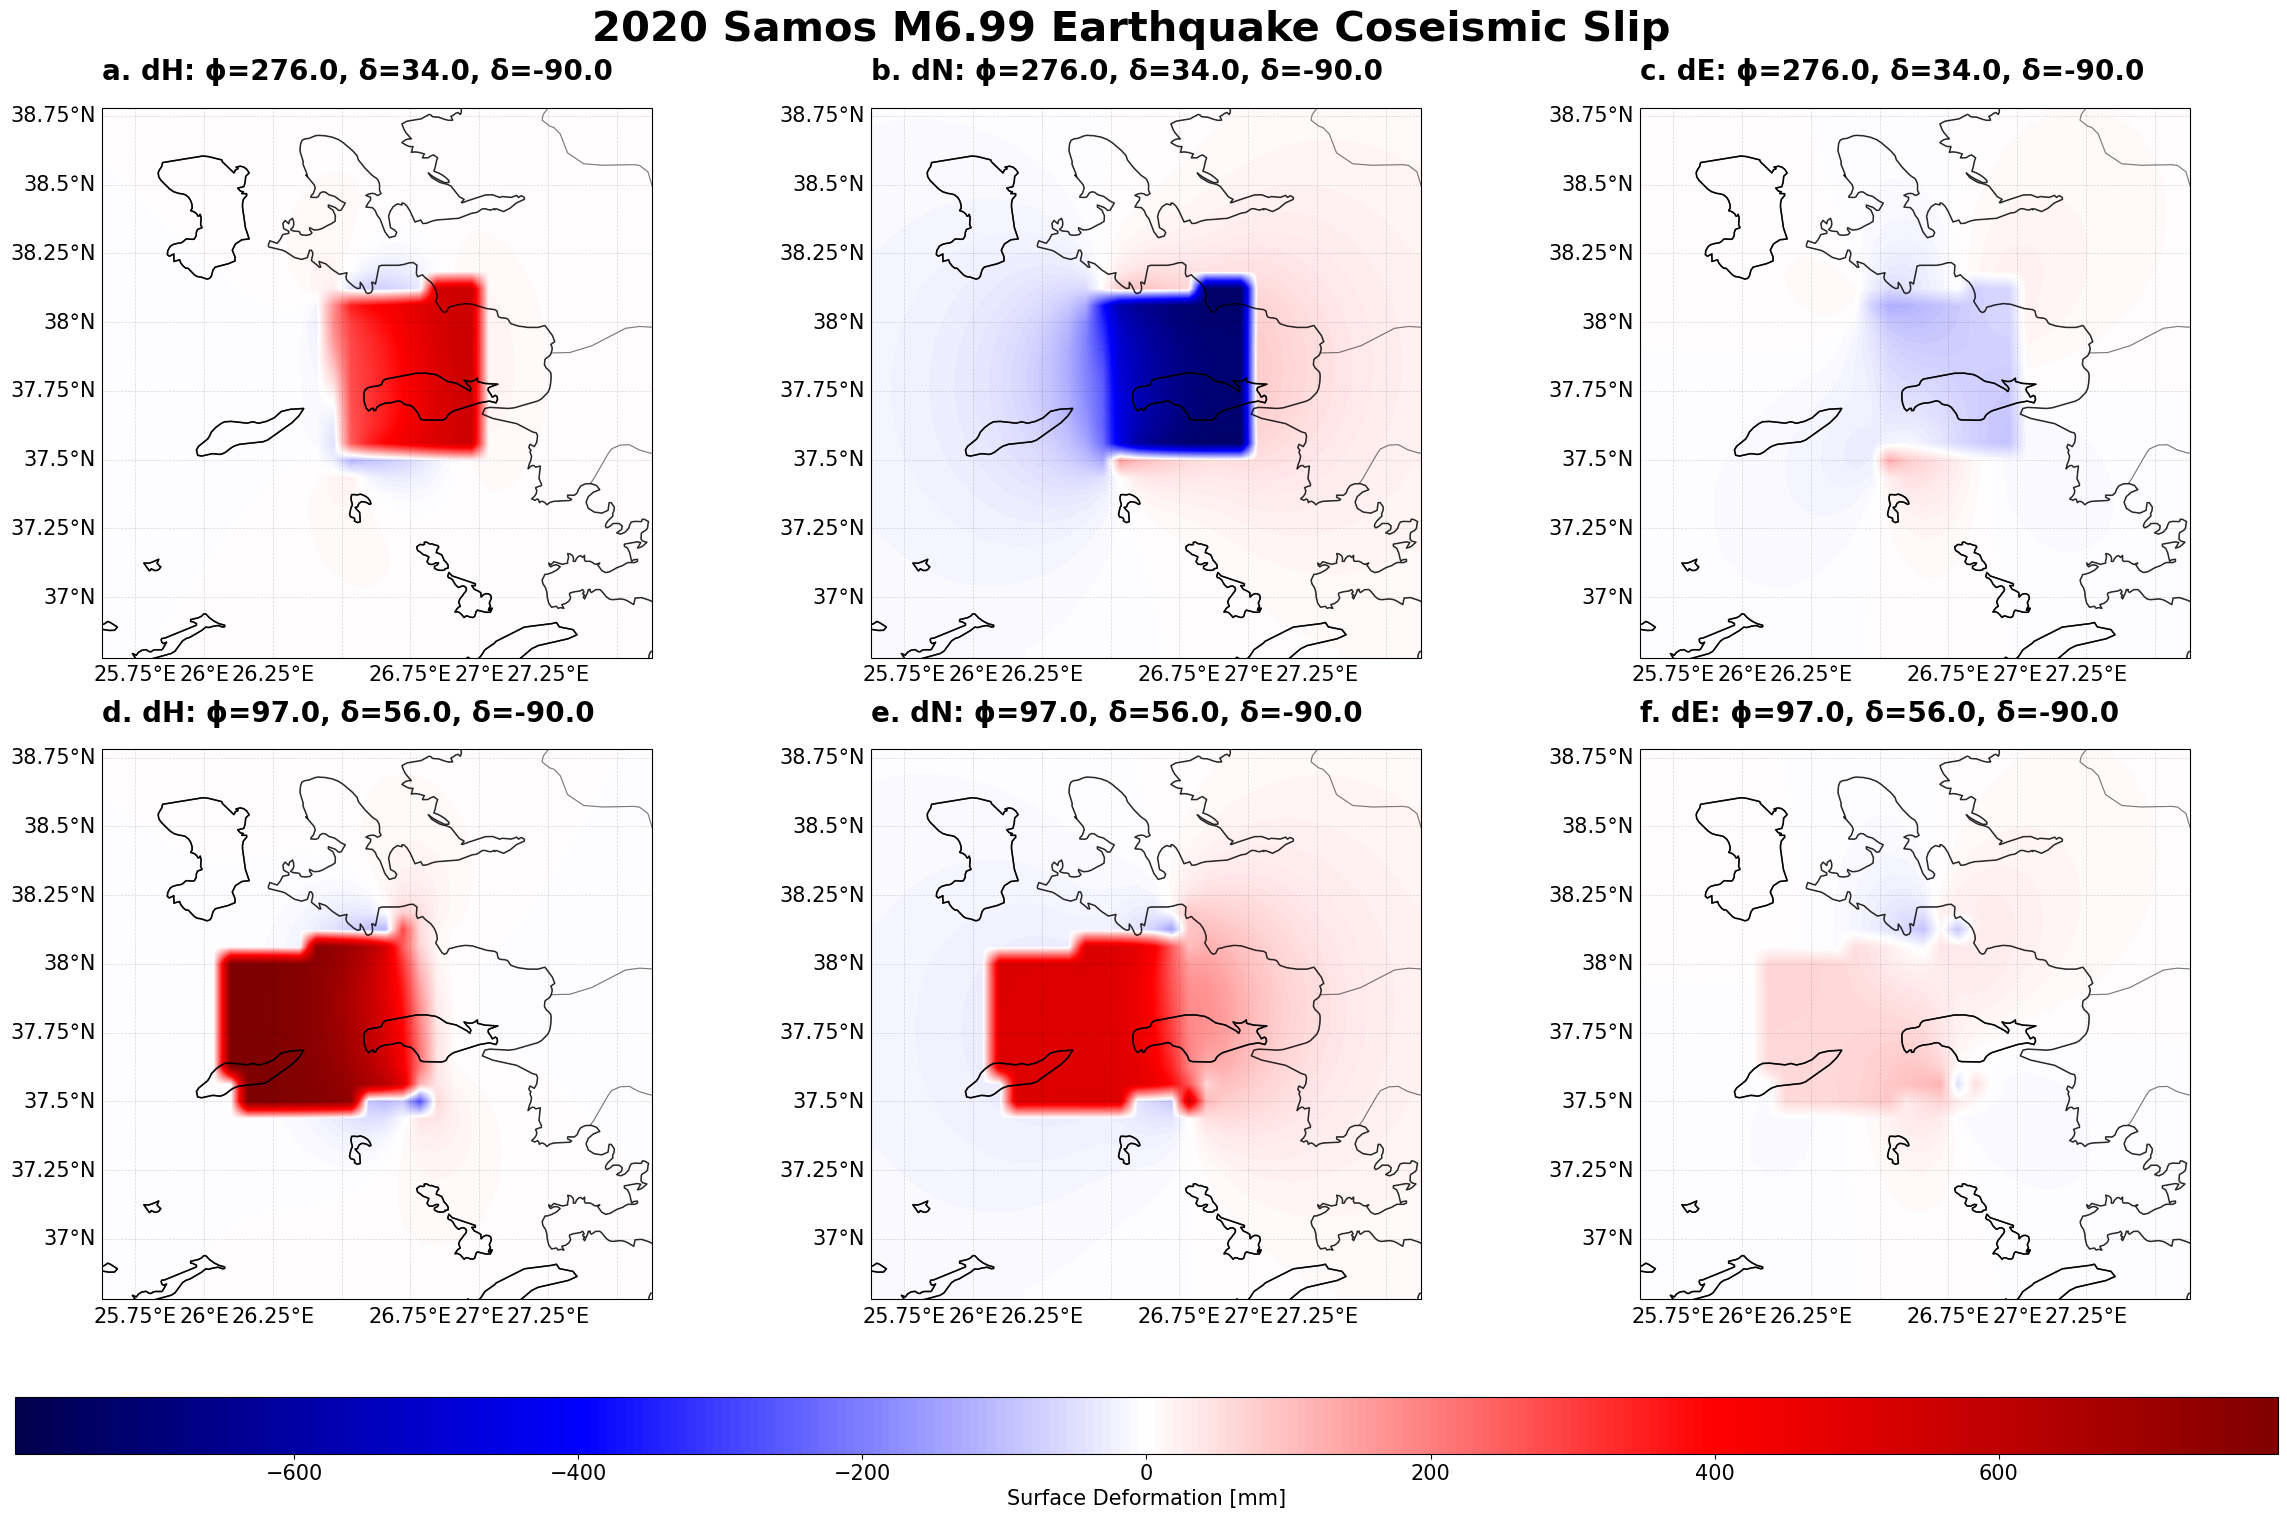

In [13]:
fig, axs = plt.subplots(2, 3, figsize=(23, 15), subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')

Contour_data = ((Z_dH1, Z_dN1, Z_dE1), (Z_dH2, Z_dN2, Z_dE2,))
Label_list = ((f'a. dH: ϕ={strike1}, δ={dip1}, δ={rake1}', f'b. dN: ϕ={strike1}, δ={dip1}, δ={rake1}', f'c. dE: ϕ={strike1}, δ={dip1}, δ={rake1}'),
              (f'd. dH: ϕ={strike2}, δ={dip2}, δ={rake2}', f'e. dN: ϕ={strike2}, δ={dip2}, δ={rake2}', f'f. dE: ϕ={strike2}, δ={dip2}, δ={rake2}'))

for i in range(2):
    for j in range (3):
        # Map Boundaries
        axs[i, j].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

        # Surface Displacement Contour Plot
        im = axs[i, j].imshow(Contour_data[i][j], interpolation='bilinear', cmap="seismic",
                       origin='lower', extent=[lon_min, lon_max, lat_min, lat_max],
                       vmax=abs(Z).max(), vmin=-abs(Z).max())

        # Adding Features
        axs[i, j].add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=1.2, edgecolor="black", alpha=0.6)
        axs[i, j].add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.8, edgecolor="black", facecolor="none", alpha=0.3)

        # Highlighting Greece using Natural Earth Country Shapefile
        shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
        reader = shpreader.Reader(shpfilename)
        countries = reader.records()
        for country in countries:
            name = country.attributes['SOVEREIGNT']
            if name == 'Greece':
                # Add Greece with your custom color
                axs[i, j].add_geometries([country.geometry], ccrs.PlateCarree(),
                                  facecolor="none", edgecolor='black', linewidth=1.0, zorder=2) #"orchid"
            else:
                # Add surrounding countries with a neutral background color
                axs[i, j].add_geometries([country.geometry], ccrs.PlateCarree(),
                                  facecolor="none", edgecolor='black', linewidth=0.3, zorder=1) #"powderblue"

        # Gridlines
        gl = axs[i, j].gridlines(
            draw_labels=True, linewidth=0.5, color="black",
            alpha=0.15, linestyle="--",
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"color": "black", "fontsize": 15}
        gl.ylabel_style = {"color": "black", "fontsize": 15}
        outline = [pe.withStroke(linewidth=2.5, foreground="black")]
        
        # Title
        axs[i, j].set_title(
            Label_list[i][j],
            fontsize=20, color="black", pad=20, loc='left', fontweight="bold"
        )

# Colorbar
cbar = fig.colorbar(im, ax=axs, orientation='horizontal', aspect=40)
cbar.ax.tick_params(labelsize=15)
cbar.set_label('Surface Deformation [mm]', fontsize=15)

fig.suptitle( # Title
    "2020 Samos M6.99 Earthquake Coseismic Slip",
    fontsize=30, color="black", fontweight="bold"
)

plt.show()

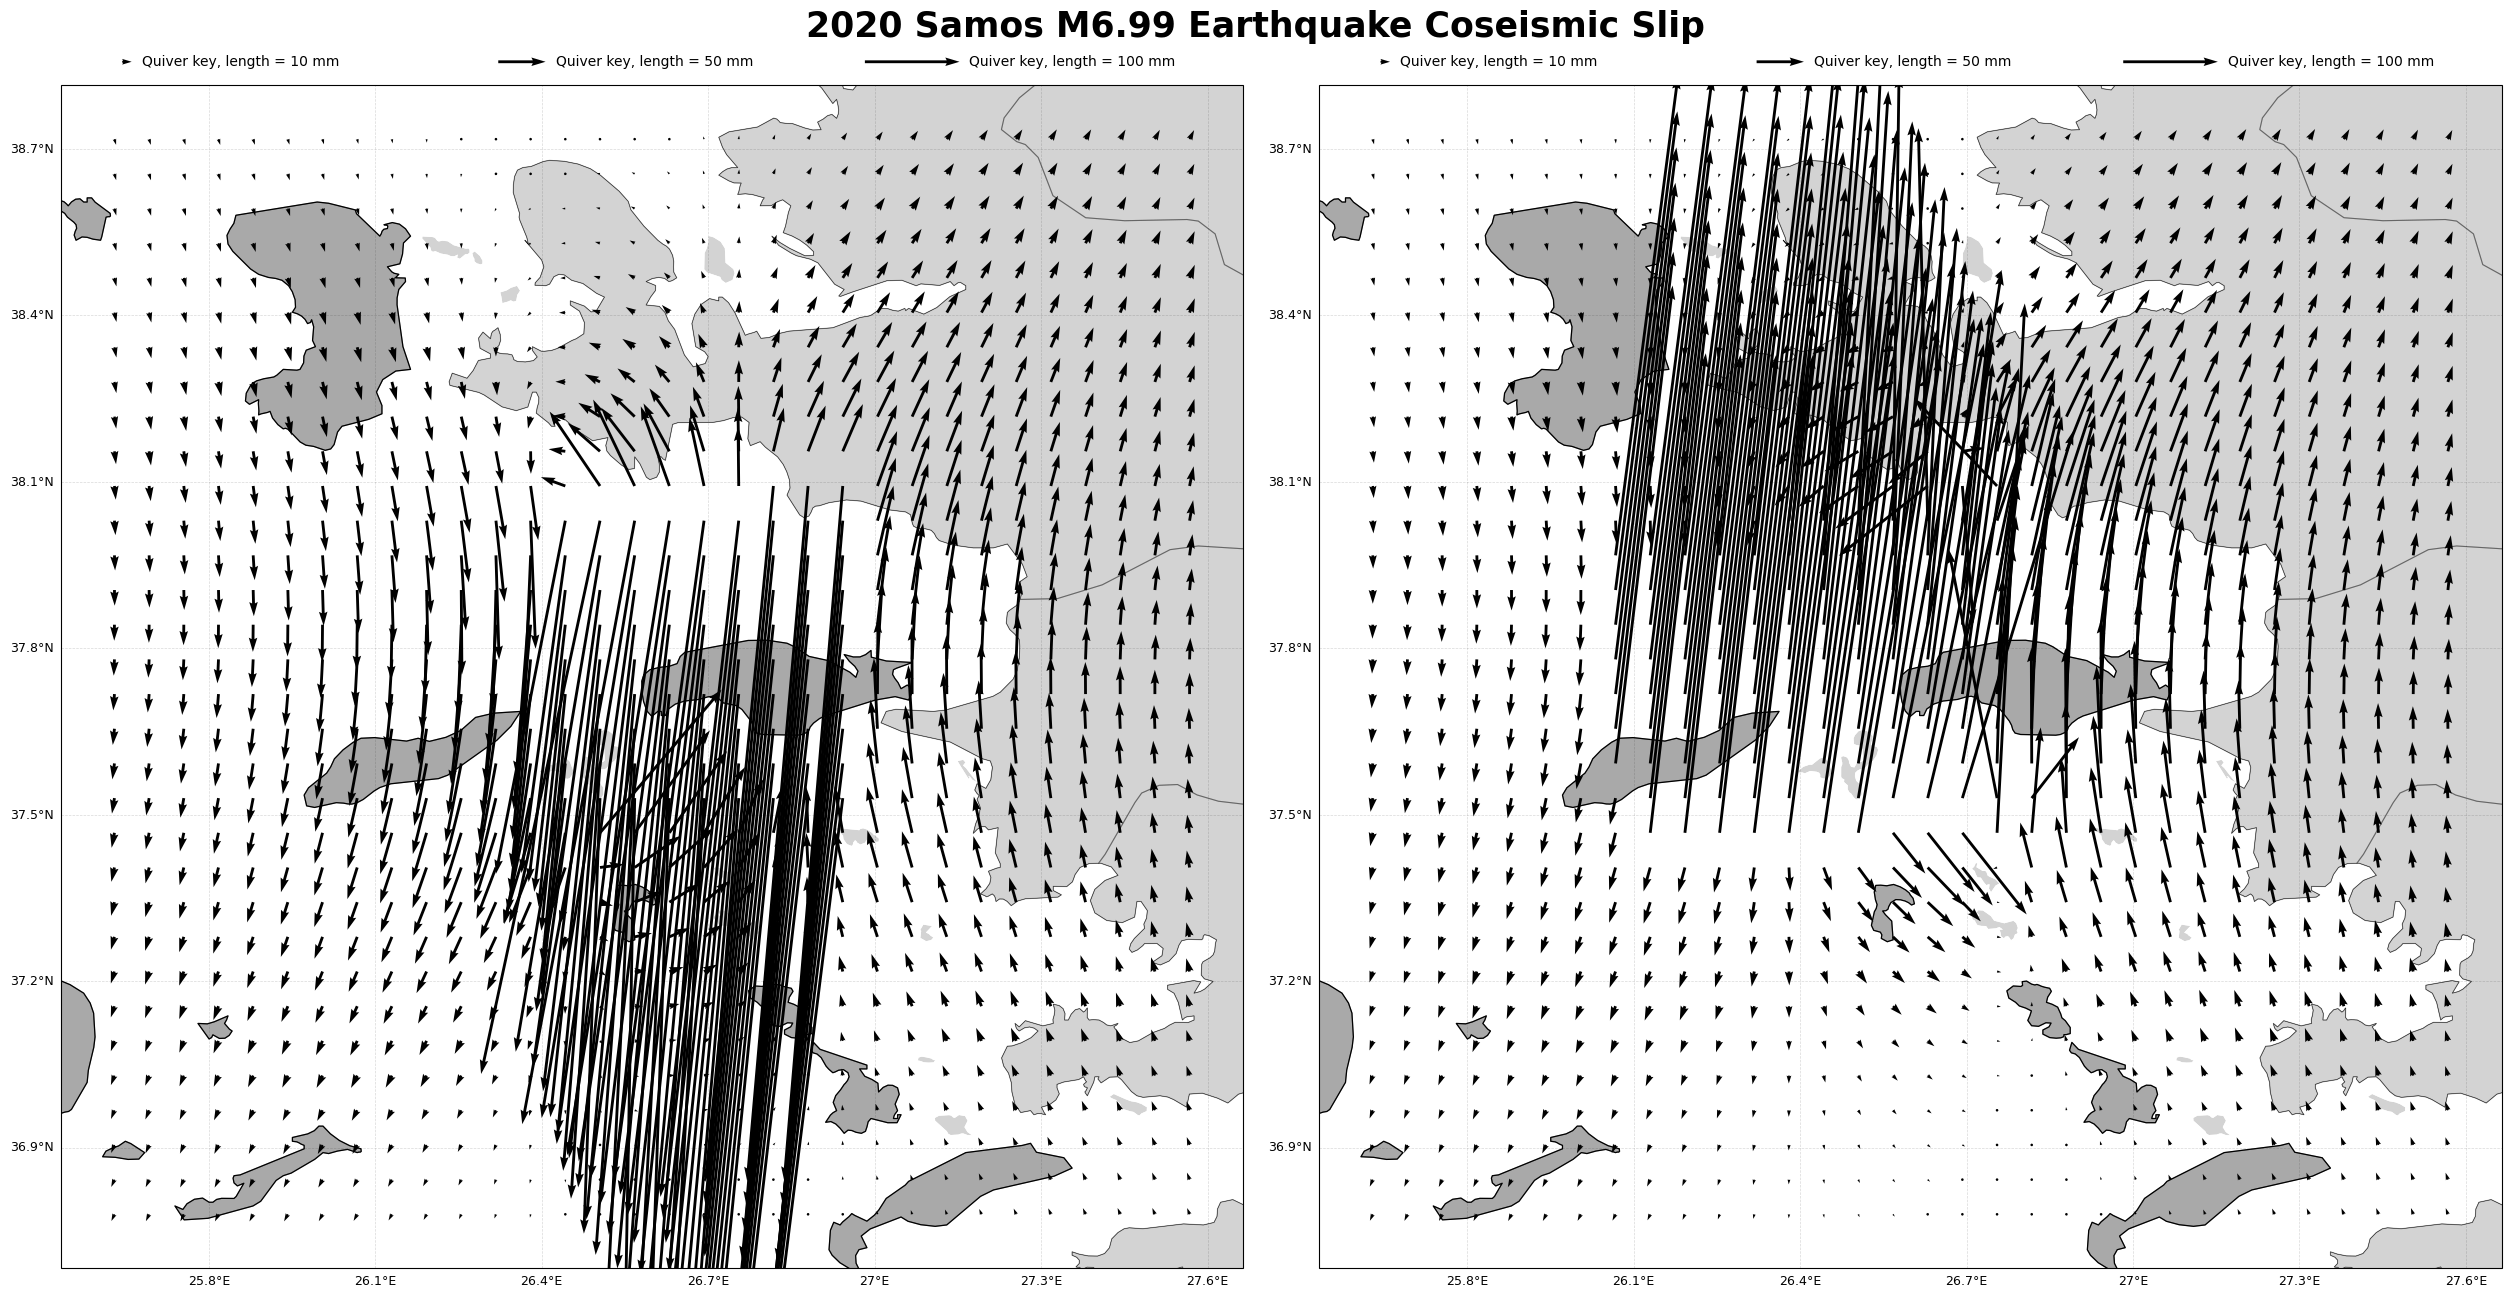

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(25, 13), subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')

Quiver_data = ((Z_dE1, Z_dN1), (Z_dE2, Z_dN2,))
Label_list = ((f'a. ϕ={strike1}, δ={dip1}, δ={rake1}'), (f'b. dH: ϕ={strike2}, δ={dip2}, δ={rake2}'))

for i in range(2):
    # Surface Displacement Contour Plot
    im = ax[i].quiver(X_mesh, Y_mesh, Quiver_data[i][0], Quiver_data[i][1], color='black', scale=1250, scale_units="width", zorder=4)
    ax[i].quiverkey(im, X=0.06, Y=1.02, U=10, label='Quiver key, length = 10 mm', labelpos='E')
    ax[i].quiverkey(im, X=0.41, Y=1.02, U=50, label='Quiver key, length = 50 mm', labelpos='E')
    ax[i].quiverkey(im, X=0.76, Y=1.02, U=100, label='Quiver key, length = 100 mm', labelpos='E')
    
    # Highlighting Greece using Natural Earth Country Shapefile
    shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
    reader = shpreader.Reader(shpfilename)
    countries = reader.records()
    for country in countries:
        name = country.attributes['SOVEREIGNT']
        if name == 'Greece':
            # Add Greece with your custom color
            ax[i].add_geometries([country.geometry], ccrs.PlateCarree(),
                              facecolor='darkgray', edgecolor='black', linewidth=0.9, zorder=2) #"orchid"
        else:
            # Add surrounding countries with a neutral background color
            ax[i].add_geometries([country.geometry], ccrs.PlateCarree(),
                              facecolor='lightgray', edgecolor='black', linewidth=0.3, zorder=1) #"powderblue"
    
    # Adding Features
    ax[i].add_feature(cfeature.LAND.with_scale("10m"), facecolor="lightgrey", edgecolor="none")
    ax[i].add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")
    ax[i].add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.8, edgecolor="black",
                   facecolor="none", alpha=0.3, zorder=3)
    
    # Gridlines
    gl = ax[i].gridlines(
        draw_labels=True, linewidth=0.5, color="black",
        alpha=0.15, linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"color": "black", "fontsize": 9}
    gl.ylabel_style = {"color": "black", "fontsize": 9}
    outline = [pe.withStroke(linewidth=2.5, foreground="black")]

    # Title
    axs[i, j].set_title(
        Label_list[i],
        fontsize=20, color="black", pad=20, loc='left', fontweight="bold"
    )
    
fig.suptitle(
    "2020 Samos M6.99 Earthquake Coseismic Slip",
    fontsize=25, color="black", fontweight="bold"
)

plt.show()

## **2. Ten Largest Earthquakes in Greece from year 2000-2020** ##

In [16]:
# Catalog Data
big10_catalog = read_events("Big10_Greece_Seismicity.xml")

eq = 1
for event in big10_catalog:
    # Read earthquake data
    origin = event.preferred_origin() or event.origins[0]
    event_time = origin.time
    focal_mech = event.preferred_focal_mechanism() or event.focal_mechanisms[0]
    moment_tensor = focal_mech.moment_tensor
    nodal_planes = focal_mech.nodal_planes
    
    plane1 = nodal_planes.nodal_plane_1
    plane2 = nodal_planes.nodal_plane_2
    
    # Declare variables
    evlat = origin.latitude #degN
    evlon = origin.longitude #degE
    evdep = origin.depth #obspy automatically converts km to m
    
    strike1 = plane1.strike #deg
    dip1 = plane1.dip #deg
    rake1 = plane1.rake #deg
    
    strike2 = plane2.strike #deg
    dip2 = plane2.dip #deg
    rake2 = plane2.rake #deg
    
    mag = event.preferred_magnitude() or event.magnitudes[0]
    mag = float(mag.mag)
    m0 = moment_tensor.scalar_moment #obspy automatically converts from dyne-cm to N-m
    
    mu = 30.0 #GPa #mu
    lam = 30.0 #GPa #lambda

    # Creating Grid
    lon_min, lon_max = evlon-1.0, evlon+1.0
    lat_min, lat_max = evlat-1.0, evlat+1.0
    X = np.arange(lon_min, lon_max, 0.0625)
    Y = np.arange(lat_min, lat_max, 0.0625)
    X_mesh, Y_mesh = np.meshgrid(X, Y)
    
    Z_dE1 = np.zeros((len(X), len(Y)))
    Z_dN1 = np.zeros((len(X), len(Y)))
    Z_dH1 = np.zeros((len(X), len(Y)))
    
    Z_dE2 = np.zeros((len(X), len(Y)))
    Z_dN2 = np.zeros((len(X), len(Y)))
    Z_dH2 = np.zeros((len(X), len(Y)))

    for i in range(len(X)):
        for j in range(len(Y)):
            # Nodal plane 1
            L, W, U = scaling (mag, m0, mu, rake1)
            ux, uy, uz = displacement (X[i], Y[j], evlon, evlat, evdep, strike1, dip1, rake1, mu, lam, U, L, W)
            dN, dE, dH = NE_rotate(ux, uy, uz, strike1)
            # Computing Z deformation (dH)
            Z_dE1[i,j] = Z_dE1[i,j]+dE
            Z_dN1[i,j] = Z_dN1[i,j]+dN
            Z_dH1[i,j] = Z_dH1[i,j]+dH
    
            # Nodal plane 2
            L, W, U = scaling (mag, m0, mu, rake2)
            ux, uy, uz = displacement (X[i], Y[j], evlon, evlat, evdep, strike2, dip2, rake2, mu, lam, U, L, W)
            dN, dE, dH = NE_rotate(ux, uy, uz, strike2)
            # Computing Z deformation (dH)
            Z_dE2[i,j] = Z_dE2[i,j]+dE
            Z_dN2[i,j] = Z_dN2[i,j]+dN
            Z_dH2[i,j] = Z_dH2[i,j]+dH
    
    Z = np.array((np.max(abs(Z_dE1)), np.max(abs(Z_dN1)), np.max(abs(Z_dH1)), np.max(abs(Z_dE2)), np.max(abs(Z_dN2)), np.max(abs(Z_dH2))))

    fig, axs = plt.subplots(2, 3, figsize=(23, 15), subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')
    
    Contour_data = ((Z_dH1, Z_dN1, Z_dE1), (Z_dH2, Z_dN2, Z_dE2,))
    Label_list = ((f'a. dH: ϕ={strike1}, δ={dip1}, δ={rake1}', f'b. dN: ϕ={strike1}, δ={dip1}, δ={rake1}', f'c. dE: ϕ={strike1}, δ={dip1}, δ={rake1}'),
                  (f'd. dH: ϕ={strike2}, δ={dip2}, δ={rake2}', f'e. dN: ϕ={strike2}, δ={dip2}, δ={rake2}', f'f. dE: ϕ={strike2}, δ={dip2}, δ={rake2}'))
    
    for i in range(2):
        for j in range (3):
            # Map Boundaries
            axs[i, j].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
            # Surface Displacement Contour Plot
            im = axs[i, j].imshow(Contour_data[i][j], interpolation='bilinear', cmap="seismic",
                           origin='lower', extent=[lon_min, lon_max, lat_min, lat_max],
                           vmax=abs(Z).max(), vmin=-abs(Z).max())
    
            # Adding Features
            axs[i, j].add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=1.2, edgecolor="black", alpha=0.6)
            axs[i, j].add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.8, edgecolor="black", facecolor="none", alpha=0.3)
    
            # Highlighting Greece using Natural Earth Country Shapefile
            shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
            reader = shpreader.Reader(shpfilename)
            countries = reader.records()
            for country in countries:
                name = country.attributes['SOVEREIGNT']
                if name == 'Greece':
                    # Add Greece with your custom color
                    axs[i, j].add_geometries([country.geometry], ccrs.PlateCarree(),
                                      facecolor="none", edgecolor='black', linewidth=1.0, zorder=2) #"orchid"
                else:
                    # Add surrounding countries with a neutral background color
                    axs[i, j].add_geometries([country.geometry], ccrs.PlateCarree(),
                                      facecolor="none", edgecolor='black', linewidth=0.3, zorder=1) #"powderblue"
    
            # Gridlines
            gl = axs[i, j].gridlines(
                draw_labels=True, linewidth=0.5, color="black",
                alpha=0.15, linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {"color": "black", "fontsize": 15}
            gl.ylabel_style = {"color": "black", "fontsize": 15}
            outline = [pe.withStroke(linewidth=2.5, foreground="black")]
            
            # Title
            axs[i, j].set_title(
                Label_list[i][j],
                fontsize=20, color="black", pad=20, loc='left', fontweight="bold"
            )
    
    # Colorbar
    cbar = fig.colorbar(im, ax=axs, orientation='horizontal', aspect=40)
    cbar.ax.tick_params(labelsize=15)
    cbar.set_label('Surface Deformation [mm]', fontsize=15)
    
    fig.suptitle( # Title
        f"EQ{eq}: M{mag} {event_time} Okada-Modelled Coseismic Slip",
        fontsize=30, color="black", fontweight="bold"
    )
    
    plt.savefig(f"Coseismic/EQ{eq}_M{mag}{event_time}_CoseismicSlip.png")
    plt.close()

# Quiver Plot
    fig, ax = plt.subplots(1, 2, figsize=(25, 13), subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')
    
    Quiver_data = ((Z_dE1, Z_dN1), (Z_dE2, Z_dN2,))
    Label_list = ((f'a. ϕ={strike1}, δ={dip1}, δ={rake1}'), (f'b. dH: ϕ={strike2}, δ={dip2}, δ={rake2}'))
    
    for i in range(2):
        # Surface Displacement Contour Plot
        im = ax[i].quiver(X_mesh, Y_mesh, Quiver_data[i][0], Quiver_data[i][1], color='black', scale=1250, scale_units="width", zorder=4)
        ax[i].quiverkey(im, X=0.06, Y=1.02, U=10, label='Quiver key, length = 10 mm', labelpos='E')
        ax[i].quiverkey(im, X=0.41, Y=1.02, U=50, label='Quiver key, length = 50 mm', labelpos='E')
        ax[i].quiverkey(im, X=0.76, Y=1.02, U=100, label='Quiver key, length = 100 mm', labelpos='E')
        
        # Highlighting Greece using Natural Earth Country Shapefile
        shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
        reader = shpreader.Reader(shpfilename)
        countries = reader.records()
        for country in countries:
            name = country.attributes['SOVEREIGNT']
            if name == 'Greece':
                # Add Greece with your custom color
                ax[i].add_geometries([country.geometry], ccrs.PlateCarree(),
                                  facecolor='darkgray', edgecolor='black', linewidth=0.9, zorder=2) #"orchid"
            else:
                # Add surrounding countries with a neutral background color
                ax[i].add_geometries([country.geometry], ccrs.PlateCarree(),
                                  facecolor='lightgray', edgecolor='black', linewidth=0.3, zorder=1) #"powderblue"
        
        # Adding Features
        ax[i].add_feature(cfeature.LAND.with_scale("10m"), facecolor="lightgrey", edgecolor="none")
        ax[i].add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")
        ax[i].add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.8, edgecolor="black",
                       facecolor="none", alpha=0.3, zorder=3)
        
        # Gridlines
        gl = ax[i].gridlines(
            draw_labels=True, linewidth=0.5, color="black",
            alpha=0.15, linestyle="--",
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"color": "black", "fontsize": 9}
        gl.ylabel_style = {"color": "black", "fontsize": 9}
        outline = [pe.withStroke(linewidth=2.5, foreground="black")]
    
        # Title
        axs[i, j].set_title(
            Label_list[i],
            fontsize=20, color="black", pad=20, loc='left', fontweight="bold"
        )
        
    fig.suptitle(
        f"EQ{eq}: M{mag} {event_time} Okada-Modelled Coseismic Slip",
        fontsize=25, color="black", fontweight="bold"
    )

    plt.savefig(f"Coseismic/EQ{eq}_M{mag}{event_time}_CoseismicSlip_2DQuiver.png")
    plt.close()
    
    eq = eq+1